In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle


In [ ]:
clean_df = pd.read_csv('../data/csv/cleaned_data.csv')
clean_df.head(1)

In [63]:
n_days = 7  # 예: 7일 이내 판매 여부


# 0. datetime 타입으로 변환 (timezone 제거 혹은 통일)
clean_df['createdAt'] = pd.to_datetime(clean_df['createdAt'], utc=True, format='mixed')
clean_df['boostedAt'] = pd.to_datetime(clean_df['boostedAt'], utc=True, format='mixed')
clean_df['crawledAt'] = pd.to_datetime(clean_df['crawledAt'], utc=True, format='mixed')


# 1. 경과 시간(일) 계산
clean_df['days_elapsed'] = (
    clean_df['crawledAt'] - clean_df['createdAt']
).dt.total_seconds() / (24 * 3600)


# 2. Target 변수 생성 함수
def make_target(row, n):
    # status 컬럼의 '거래완료'를 의미하는 정확한 텍스트 확인 필요 (예: 'Completed', 'Sold' 등)
    is_sold = row['status'] != 'Ongoing'  # 혹은 status_detail 사용

    if is_sold and row['days_elapsed'] <= n:
        return 1  # n일 이내 판매됨
    elif not is_sold and row['days_elapsed'] > n:
        return 0  # n일이 지났는데도 안 팔림
    else:
        return np.nan  # 아직 n일이 안 지났는데 안 팔린 상태 (보류)


clean_df['target_n_days'] = clean_df.apply(lambda x: make_target(x, n_days), axis=1)

# 판별 불가능한(보류된) 데이터 학습에서 제외
train_df = clean_df.dropna(subset=['target_n_days']).copy()
train_df['target_n_days'] = train_df['target_n_days'].astype(int)


In [64]:
# 1. 비율 관련 피처 (조회수 0으로 나누는 것 방지)
train_df['favorite_per_view'] = train_df['favoriteCount'] / (train_df['viewCount'] + 1)
train_df['chat_per_view'] = train_df['chatCount'] / (train_df['viewCount'] + 1)

# 2. 가격 로그 변환 (이상치 영향을 줄이기 위함)
train_df['price_log'] = np.log1p(train_df['price'])

In [ ]:
cols = [
    # --- 판매자 관점에서 볼 수 있는 현재 반응도 데이터 ---
    'status',
    'price',
    'price_log',
    'price_ratio_to_brand',
    'sellerTemperature',
    'title_len',
    'has_keyword_new',
    'title',
    'content',
    'region_name',
    # --- 구매자 관점에서 볼 수 있는 현재 반응도 데이터 ---
    'viewCount',
    'favoriteCount',
    'chatCount',
    'favorite_per_view',
    'chat_per_view',
    'is_boosted',
    'target_n_days',
]

In [66]:
train_df = train_df[cols].copy()

In [67]:
train_df.to_csv('../data/csv/train_df.csv', index=False)

In [2]:
df = pd.read_csv('../data/csv/train_df_enriched.csv')
df.head(1)

,status,price,price_log,price_ratio_to_brand,sellerTemperature,title_len,has_keyword_new,title,content,region_name,viewCount,favoriteCount,chatCount,favorite_per_view,chat_per_view,is_boosted,target_n_days,brandName
0,Ongoing,22000,9.998843,0.223793,75.9,20,0,마리마켓 트렌치자켓 롤업팬츠 세트 S,"마리마켓 트렌치자켓 롤업팬츠 세트\n베이지 색상\n자켓, 팬츠 둘다 사이즈 S\n미...",역삼1동,168,3,0,0.017751,0.0,1,0,mari market


In [ ]:
import pandas as pd
from sentence_transformers import SentenceTransformer

# 한국어 문장 임베딩에 성능이 좋은 모델 로드 (GPU가 있다면 자동으로 할당됩니다)
# 처음 실행 시 모델을 다운로드하므로 시간이 조금 걸릴 수 있습니다.
model_name = 'jhgan/ko-sroberta-multitask'
embedder = SentenceTransformer(model_name)


def create_text_embeddings(df, text_columns):
    """
    지정된 텍스트 컬럼들을 임베딩 벡터로 변환하여 기존 데이터프레임에 병합합니다.
    """
    df_embedded = df.copy()

    for col in text_columns:
        print(f'[{col}] 임베딩 추출 중...')
        # 텍스트 결측치 처리 (빈 문자열로)
        texts = df_embedded[col].fillna('').tolist()

        # 임베딩 생성 (768차원 벡터로 변환됨)
        embeddings = embedder.encode(texts, show_progress_bar=True)

        # 임베딩 결과를 데이터프레임 컬럼으로 변환
        emb_df = pd.DataFrame(
            embeddings,
            columns=[f'{col}_emb_{i}' for i in range(embeddings.shape[1])],
            index=df_embedded.index,
        )

        # 기존 텍스트 컬럼 삭제 및 임베딩 컬럼 병합
        df_embedded = df_embedded.drop(columns=[col])
        df_embedded = pd.concat([df_embedded, emb_df], axis=1)

    return df_embedded


# 사용 예시 (df는 원본 데이터프레임)
text_cols = ['title', 'content']
df_vectorized = create_text_embeddings(df, text_cols)
df_vectorized.to_csv('../data/csv/vectorized_df.csv', index=False)

In [3]:
vec_df = pd.read_csv('../data/csv/vectorized_df.csv')

vec_df.head(1)

,status,price,price_log,price_ratio_to_brand,sellerTemperature,title_len,has_keyword_new,region_name,viewCount,favoriteCount,...,content_emb_758,content_emb_759,content_emb_760,content_emb_761,content_emb_762,content_emb_763,content_emb_764,content_emb_765,content_emb_766,content_emb_767
0,Ongoing,22000,9.998843,0.223793,75.9,20,0,역삼1동,168,3,...,-0.096122,-0.015974,-0.284907,0.890095,0.412497,-0.284411,-0.07036,0.08028,-0.071742,-0.379537


In [4]:
vec_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 131842 entries, 0 to 131841
Columns: 1552 entries, status to content_emb_767
dtypes: float64(1541), int64(8), str(3)
memory usage: 1.5 GB


In [5]:
cols_to_drop = [
    # --- 판매자 관점에서 볼 수 있는 현재 반응도 데이터 ---
    'status',
    'price',
    # --- 구매자 관점에서 볼 수 있는 현재 반응도 데이터 ---
    'viewCount',
    'favoriteCount',
    'chatCount',
    'favorite_per_view',
    'chat_per_view',
    'is_boosted',
    'target_n_days',
]

In [6]:
X_train = vec_df.drop(cols_to_drop, axis=1)
y_train = vec_df['target_n_days']

categorical_features = ['region_name', 'brandName']

In [ ]:
# 1. Optuna용 앙상블 학습 함수 (인자로 cat_features 추가)
def train_ensemble_for_optuna(X_tr, y_tr, params, cat_features, n_models=5):
    majority_idx = y_tr[y_tr == 0.0].index
    minority_idx = y_tr[y_tr == 1.0].index

    majority_idx_shuffled = shuffle(majority_idx, random_state=42)
    majority_chunks = np.array_split(majority_idx_shuffled, n_models)

    models = []
    for chunk_idx in majority_chunks:
        train_idx = chunk_idx.tolist() + minority_idx.tolist()

        X_subset = X_tr.loc[train_idx]
        y_subset = y_tr.loc[train_idx]

        # 범주형 데이터 지정
        train_pool = Pool(data=X_subset, label=y_subset, cat_features=cat_features)

        model = CatBoostClassifier(**params)
        model.fit(train_pool, verbose=False)
        models.append(model)

    return models


# 2. 앙상블 예측 함수 (🌟 수정됨: 에러 방지를 위해 Pool 객체 사용)
def predict_ensemble(models, X_val, cat_features):
    predictions = np.zeros(len(X_val))
    # 예측할 때도 데이터프레임이 아닌 Pool 형태로 넣어줘야 CatBoost가 범주형을 인식합니다.
    test_pool = Pool(data=X_val, cat_features=cat_features)

    for model in models:
        predictions += model.predict_proba(test_pool)[:, 1]
    return predictions / len(models)


# 3. 데이터 분할 (🌟 수정됨: Optuna 평가의 일관성을 위해 밖에서 한 번만 분할)
X_opt_tr, X_opt_val, y_opt_tr, y_opt_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)


# 4. Optuna 목적 함수(Objective Function) 정의
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 15.0),
        'random_strength': trial.suggest_float('random_strength', 0.01, 1.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'loss_function': 'Logloss',
        'eval_metric': 'Logloss',
        'task_type': 'GPU',
        'bootstrap_type': 'Bayesian',  # 🌟 수정됨: GPU 환경에서 bagging_temperature 쓸 때 필수
        'verbose': False,
    }

    # 미리 고정해둔 분할 데이터를 넣어서 학습
    models = train_ensemble_for_optuna(
        X_opt_tr, y_opt_tr, params, categorical_features, n_models=5
    )

    # 예측 수행
    val_proba = predict_ensemble(models, X_opt_val, categorical_features)

    # PR-AUC 계산
    score = average_precision_score(y_opt_val, val_proba)

    return score


# 5. Optuna 최적화 실행
study = optuna.create_study(direction='maximize')
print('🔥 Optuna + 앙상블 하이퍼파라미터 탐색을 시작합니다...')
study.optimize(objective, n_trials=30)

print('\n🏆 [Best Trial]')
print(f'최고 PR-AUC 점수: {study.best_value:.4f}')
print('최적의 파라미터:')
for key, value in study.best_params.items():
    print(f'  {key}: {value}')

[I 2026-03-09 23:13:21,677] A new study created in memory with name: no-name-0a1e8fdb-004a-4d68-a45f-48885779c832


🔥 Optuna + 앙상블 하이퍼파라미터 탐색을 시작합니다...


[I 2026-03-09 23:17:13,452] Trial 0 finished with value: 0.10889153303994102 and parameters: {'iterations': 935, 'learning_rate': 0.027241495350336625, 'depth': 5, 'l2_leaf_reg': 10.6316410517669, 'random_strength': 0.030573455952275903, 'bagging_temperature': 0.7466772588236661}. Best is trial 0 with value: 0.10889153303994102.
[I 2026-03-09 23:17:58,649] Trial 1 finished with value: 0.10775390195663949 and parameters: {'iterations': 348, 'learning_rate': 0.036648356272271934, 'depth': 6, 'l2_leaf_reg': 2.335157413459253, 'random_strength': 0.08036158738405888, 'bagging_temperature': 0.2876365748460443}. Best is trial 0 with value: 0.10889153303994102.
[I 2026-03-09 23:23:57,097] Trial 2 finished with value: 0.09993946612155348 and parameters: {'iterations': 623, 'learning_rate': 0.011312794390156214, 'depth': 7, 'l2_leaf_reg': 12.967257250698019, 'random_strength': 0.14096376347239745, 'bagging_temperature': 0.3606324993174318}. Best is trial 0 with value: 0.10889153303994102.
[I 202


🏆 [Best Trial]
최고 PR-AUC 점수: 0.1089
최적의 파라미터:
  iterations: 935
  learning_rate: 0.027241495350336625
  depth: 5
  l2_leaf_reg: 10.6316410517669
  random_strength: 0.030573455952275903
  bagging_temperature: 0.7466772588236661



🌟 [최종 모델 학습 및 Permutation Importance 추출]


C:\Users\hanvv\AppData\Local\Temp\ipykernel_22708\1911986537.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


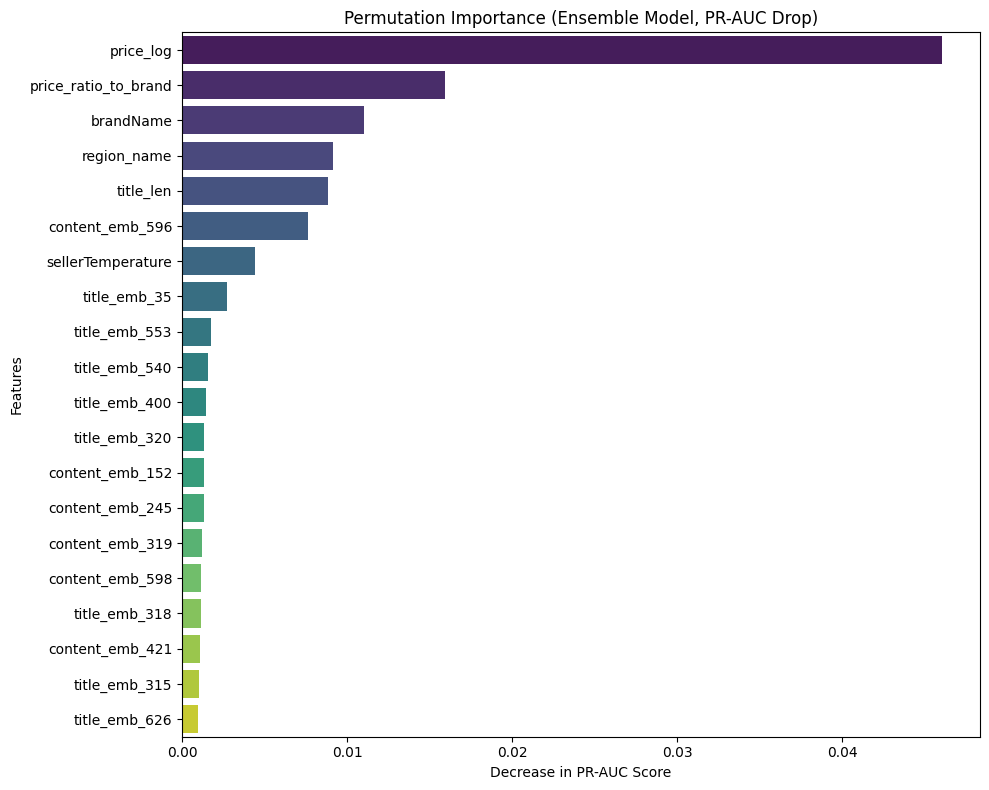


[상세 변수 중요도 수치 (Top 10)]
                Feature  Importance
0             price_log    0.046027
1  price_ratio_to_brand    0.015912
2             brandName    0.011041
3           region_name    0.009118
4             title_len    0.008845
5       content_emb_596    0.007633
6     sellerTemperature    0.004393
7          title_emb_35    0.002708
8         title_emb_553    0.001729
9         title_emb_540    0.001597


In [ ]:
import pandas as pd
import seaborn as sns


# 1. Permutation Importance 계산 함수 정의
def get_ensemble_permutation_importance(
    models, X_val, y_val, cat_features, metric_fn=average_precision_score
):
    """
    각 피처를 무작위로 섞었을 때 평가지표(PR-AUC)가 얼마나 하락하는지 계산합니다.
    """
    # 1) 섞기 전 원본 데이터의 기준(Baseline) 점수 계산
    baseline_proba = predict_ensemble(models, X_val, cat_features)
    baseline_score = metric_fn(y_val, baseline_proba)

    importances = {}

    # 2) 각 컬럼을 순회하며 하나씩 섞어보고 점수 하락폭 측정
    for col in X_val.columns:
        X_val_shuffled = X_val.copy()

        # 해당 컬럼의 데이터만 무작위로 섞음 (.values를 써서 인덱스 꼬임 방지)
        X_val_shuffled[col] = np.random.permutation(X_val_shuffled[col].values)

        # 섞인 데이터로 예측 및 점수 계산
        shuffled_proba = predict_ensemble(models, X_val_shuffled, cat_features)
        shuffled_score = metric_fn(y_val, shuffled_proba)

        # 중요도 = 기존 점수 - 섞은 후 점수 (많이 떨어질수록 중요한 변수)
        importance_score = baseline_score - shuffled_score
        importances[col] = importance_score

    # 데이터프레임으로 변환 후 내림차순 정렬
    df_imp = (
        pd.DataFrame(
            {
                'Feature': list(importances.keys()),
                'Importance': list(importances.values()),
            }
        )
        .sort_values(by='Importance', ascending=False)
        .reset_index(drop=True)
    )

    return df_imp


# ==========================================
# 🚀 Optuna 완료 후 최종 모델 학습 및 중요도 시각화
# ==========================================

print('\n🌟 [최종 모델 학습 및 Permutation Importance 추출]')

# 1. Optuna에서 찾은 베스트 파라미터 가져오기
best_params = study.best_params
best_params['loss_function'] = 'Logloss'
best_params['eval_metric'] = 'Logloss'
best_params['task_type'] = 'GPU'
best_params['bootstrap_type'] = 'Bayesian'
best_params['verbose'] = False

# 2. 베스트 파라미터로 최종 앙상블 모델 학습
final_models = train_ensemble_for_optuna(
    X_opt_tr, y_opt_tr, best_params, categorical_features, n_models=5
)

# 3. 검증 데이터(X_opt_val)를 이용해 Permutation Importance 계산
perm_importances = get_ensemble_permutation_importance(
    final_models, X_opt_val, y_opt_val, categorical_features
)

# 4. 결과 시각화
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=perm_importances.head(20),  # 상위 20개만 출력
    palette='viridis',
)
plt.title('Permutation Importance (Ensemble Model, PR-AUC Drop)')
plt.xlabel('Decrease in PR-AUC Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 상세 수치 출력
print('\n[상세 변수 중요도 수치 (Top 10)]')
print(perm_importances.head(10))

🌟 [최적 임계값 탐색 결과] 🌟
👉 Best Threshold : 0.2337
👉 Best F1-Score  : 0.1811

✅ [최적 임계값 적용 후 Classification Report]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     26066
           1       0.24      0.15      0.18       303

    accuracy                           0.98     26369
   macro avg       0.62      0.57      0.59     26369
weighted avg       0.98      0.98      0.98     26369



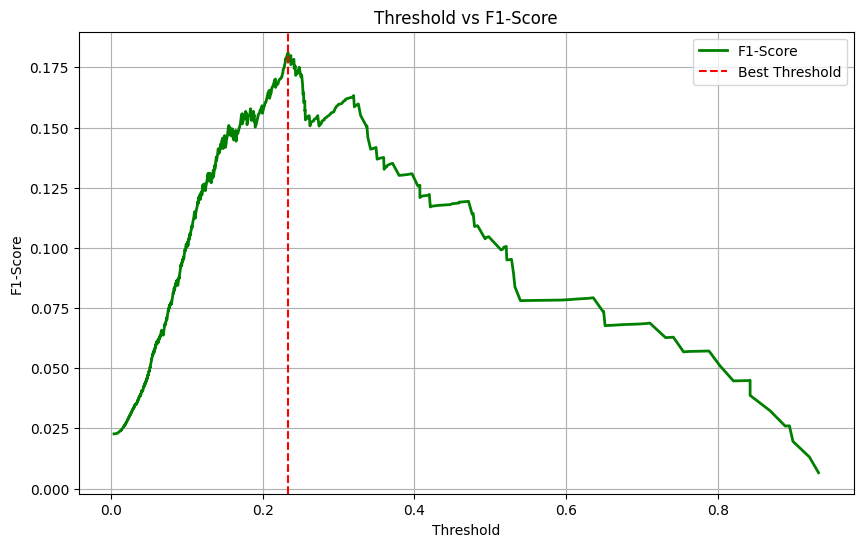

In [15]:
# 검증용 데이터(X_val)에 대한 앙상블 확률 계산
def get_ensemble_proba(models, X_val):
    predictions = np.zeros(len(X_val))
    for model in models:
        # 클래스 1.0(정답)일 확률만 가져와서 누적
        predictions += model.predict_proba(X_val)[:, 1]

    # 모델 개수로 나누어 평균 확률(Soft Voting) 계산
    avg_proba = predictions / len(models)
    return avg_proba


def find_optimal_threshold(y_true, y_proba):
    # 1. 가능한 모든 임계값과 그에 따른 정밀도, 재현율 계산
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)

    # 2. 각 임계값에서의 F1-score 계산 (분모가 0이 되는 것을 방지하기 위해 1e-10 추가)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

    # 3. F1-score가 가장 높은 지점의 인덱스 추출
    best_idx = np.argmax(f1_scores)

    # 4. 최적의 임계값과 그때의 F1-score
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print('🌟 [최적 임계값 탐색 결과] 🌟')
    print(f'👉 Best Threshold : {best_threshold:.4f}')
    print(f'👉 Best F1-Score  : {best_f1:.4f}\n')

    return best_threshold


def plot_threshold_curve(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

    plt.figure(figsize=(10, 6))
    # thresholds는 precisions/recalls보다 길이가 1 짧으므로 슬라이싱 필요
    plt.plot(thresholds, f1_scores[:-1], label='F1-Score', color='green', linewidth=2)
    plt.axvline(
        x=thresholds[np.argmax(f1_scores)],
        color='red',
        linestyle='--',
        label='Best Threshold',
    )

    plt.title('Threshold vs F1-Score')
    plt.xlabel('Threshold')
    plt.ylabel('F1-Score')
    plt.legend()
    plt.grid(True)
    plt.show()


# 최적 임계값 구하기 (y_opt_val은 검증 데이터의 실제 정답)
y_proba = get_ensemble_proba(final_models, X_opt_val)
best_threshold = find_optimal_threshold(y_opt_val, y_proba)

# 확률값이 best_threshold 이상이면 1.0, 아니면 0.0으로 변환
y_pred_custom = (y_proba >= best_threshold).astype(float)

# 최종 성능 확인
print('✅ [최적 임계값 적용 후 Classification Report]')
print(classification_report(y_opt_val, y_pred_custom))

# 그래프 그리기
plot_threshold_curve(y_opt_val, y_proba)

In [10]:
import os


def save_ensemble_models(models, save_dir='ensemble_models'):
    """
    학습된 앙상블 모델 리스트를 지정한 폴더에 저장합니다.
    """
    # 폴더가 없으면 생성
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    for i, model in enumerate(models):
        # catboost_model_0.cbm, catboost_model_1.cbm 형태로 저장
        file_path = os.path.join(save_dir, f'catboost_model_{i}.cbm')
        model.save_model(file_path)

    print(
        f"✅ {len(models)}개의 앙상블 모델이 '{save_dir}' 폴더에 안전하게 저장되었습니다."
    )


# 사용 예시 (위에서 학습한 final_models를 저장)
save_ensemble_models(final_models, save_dir='../data/models/my_best_ensemble')

✅ 5개의 앙상블 모델이 '../data/models/my_best_ensemble' 폴더에 안전하게 저장되었습니다.


In [ ]:
# 앙상블 모델 중 첫 번째 모델(어차피 모두 동일한 피처로 학습됨)에서 정보 추출
reference_model = final_models[0]

# 1. 모델이 기대하는 정확한 피처 이름과 순서 리스트 추출
expected_feature_names = reference_model.feature_names_

print(f'모델이 학습한 총 피처 개수: {len(expected_feature_names)}개')
print(f'피처 순서 (상위 10개): {expected_feature_names[:10]}')

# 2. 범주형 피처(cat_features)로 지정되었던 컬럼 정보 추출
# 만약 인덱스로 출력된다면, expected_feature_names[idx]로 이름을 매칭할 수 있습니다.
cat_features_info = reference_model.get_param('cat_features')
print(f'\n학습 당시 범주형으로 지정된 피처: {cat_features_info}')  # 이게 좀 이상한듯..

모델이 학습한 총 피처 개수: 1543개
피처 순서 (상위 10개): ['price_log', 'price_ratio_to_brand', 'sellerTemperature', 'title_len', 'has_keyword_new', 'region_name', 'brandName', 'title_emb_0', 'title_emb_1', 'title_emb_2']

학습 당시 범주형으로 지정된 피처: None


In [ ]:
import pandas as pd
from sentence_transformers import SentenceTransformer

train_df = pd.read_csv('../data/csv/train_df_enriched.csv')
brand_mean_dict = train_df.groupby('brandName')['price'].mean().to_dict()


def predict_new_item(
    new_data_dict,
    models,
    embedder,
    best_threshold,
    text_cols=['title', 'content'],
    cat_cols=['region_name', 'brandName'],
):
    """
    새로운 임의의 데이터를 입력받아 앙상블 모델의 예측 결과를 반환합니다.
    """
    print('🔍 새로운 데이터 추론을 시작합니다...')

    new_data_dict['price_log'] = np.log1p(
        new_data_dict['price']
    )  # 학습 때 로그 변환한 피처도 포함

    b_mean = brand_mean_dict.get(new_data_dict['brandName'], new_data_dict['price'])
    price_ratio_to_brand = new_data_dict['price'] / (b_mean + 1)
    new_data_dict['price_ratio_to_brand'] = price_ratio_to_brand

    # 1. 딕셔너리 형태의 입력값을 DataFrame으로 변환 (1행짜리 데이터)
    df_new = pd.DataFrame([new_data_dict])

    # 2. 텍스트 피처 임베딩 (학습 때와 동일한 처리)
    df_processed = df_new.copy()
    for col in text_cols:
        text_list = df_processed[col].fillna('').tolist()
        # 임베딩 추출
        emb = embedder.encode(text_list)
        # 학습 때와 동일한 컬럼명(예: content_emb_0)으로 데이터프레임 생성
        emb_df = pd.DataFrame(
            emb, columns=[f'{col}_emb_{i}' for i in range(emb.shape[1])]
        )

        # 원본 텍스트 컬럼 삭제 후 임베딩 컬럼 병합
        df_processed = df_processed.drop(columns=[col])
        df_processed = pd.concat([df_processed, emb_df], axis=1)

    # (주의) 만약 이전 단계에서 PCA로 차원 축소를 하셨다면,
    # 모델에 넣기 전에 여기서 pca.transform()을 수행하여 차원을 맞춰주어야 합니다.

    # 3. CatBoost Pool 객체로 포장 (범주형 변수 지정 필수!)
    new_pool = Pool(data=df_processed, cat_features=cat_cols)

    # 4. 앙상블 모델 예측 확률 계산 (Soft Voting)
    pred_proba = np.zeros(1)
    for model in models:
        # 클래스 1.0에 대한 확률값 누적
        pred_proba += model.predict_proba(new_pool)[:, 1]

    # 모델 개수로 나누어 최종 평균 확률 도출
    avg_proba = (pred_proba / len(models))[0]

    # 5. 최적 임계값(Threshold)을 적용하여 최종 클래스(0 또는 1) 판별
    final_class = 1.0 if avg_proba >= best_threshold else 0.0

    return avg_proba, final_class


# ==========================================
# 💡 실제 사용 예시
# ==========================================

# 한국어 문장 임베딩에 성능이 좋은 모델 로드 (GPU가 있다면 자동으로 할당됩니다)
# 처음 실행 시 모델을 다운로드하므로 시간이 조금 걸릴 수 있습니다.
model_name = 'jhgan/ko-sroberta-multitask'
embedder = SentenceTransformer(model_name)

# 가상의 새로운 데이터 (학습 데이터에 있던 피처들을 모두 포함해야 합니다)
sample_data = {
    'title': '나이키 맨투맨 L사이즈 거의 새것',
    'content': '백화점에서 정가 주고 샀는데 사이즈 미스로 팝니다. 실착 1회입니다.',
    'price': 5000,
    'sellerTemperature': 41.5,
    'title_len': 16,
    'has_keyword_new': 1,
    'region_name': '역삼1동',
    'brandName': '나이키',
}

# 함수 실행 (이전에 구하신 trained_models, embedder, best_threshold 변수 활용)
# best_threshold에는 Optuna와 Threshold 탐색을 통해 얻은 최적의 소수점 값(예: 0.15 등)을 넣습니다.
probability, prediction = predict_new_item(
    new_data_dict=sample_data,
    models=final_models,
    embedder=embedder,
    best_threshold=0.2,  # 예시 임계값
)

print('\n📊 [예측 결과]')
print(f'1.0일 확률: {probability * 100:.2f}%')
print(
    f'최종 판별: {"타겟(1.0) 입니다 🚨" if prediction == 1.0 else "일반(0.0) 입니다 ✅"}'
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: jhgan/ko-sroberta-multitask
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🔍 새로운 데이터 추론을 시작합니다...

📊 [예측 결과]
1.0일 확률: 1.30%
최종 판별: 일반(0.0) 입니다 ✅
